# Proyecto: Análisis de Churn en Telecom-X
**Autor:** Christian Quidel  
**Objetivo:** Identificar por qué los clientes abandonan el servicio de Telecom-X, mediante un pipeline ETL completo seguido de análisis exploratorio y modelado predictivo.

---
## Diccionario de datos

| Variable | Descripción |
|---|---|
| customerID | Identificador único del cliente |
| Churn | Si el cliente dejó la empresa (bool) |
| gender | Género del cliente |
| SeniorCitizen | Si el cliente tiene 65 años o más |
| Partner | Si el cliente tiene pareja |
| Dependents | Si el cliente tiene dependientes |
| tenure | Meses de contrato activo |
| PhoneService | Suscripción al servicio telefónico |
| MultipleLines | Suscripción a más de una línea telefónica |
| InternetService | Tipo de proveedor de internet |
| OnlineSecurity | Suscripción adicional de seguridad en línea |
| OnlineBackup | Suscripción adicional de respaldo en línea |
| DeviceProtection | Suscripción adicional de protección del dispositivo |
| TechSupport | Suscripción adicional de soporte técnico |
| StreamingTV | Suscripción de televisión por streaming |
| StreamingMovies | Suscripción de películas por streaming |
| Contract | Tipo de contrato (mensual, anual, bi-anual) |
| PaperlessBilling | Si el cliente recibe factura digital |
| PaymentMethod | Método de pago |
| Charges.Monthly | Cargo mensual total |
| Charges.Total | Cargo total acumulado |

---
# Bloque 1: Importaciones y Configuración

In [ ]:
import pandas as pd
import numpy as np
import requests
import json
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import chi2_contingency

warnings.filterwarnings('ignore')

# Configuración global -------------------------------------
pd.options.display.float_format = "{:.2f}".format
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

# Paleta de colores -------------------------------------
COLORES = {
    'churn'    : '#E74C3C',   # rojo  → clientes que SI se van
    'no_churn' : '#2E86AB',   # azul  → clientes que NO se van
    'neutro'   : '#95A5A6',
    'acento'   : '#F39C12',
}
PALETTE_CHURN = [COLORES['no_churn'], COLORES['churn']]



print("check")

✅ Librerías importadas correctamente.


---
# Bloque 2: Extracción

Se usa el enlace `raw` para obtener el JSON directamente.

In [ ]:
URL_RAW = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json'

# Agrego manejo de excepciones de red porque en entornos como colab
# la conectividad puede fallar silenciosamente sin un try/except
try:
    respuesta = requests.get(URL_RAW, timeout=10)
    respuesta.raise_for_status()
    json_nativo = json.loads(respuesta.text)
    df_raw = pd.json_normalize(json_nativo)
    print(f"check > {df_raw.shape[0]} filas y {df_raw.shape[1]} columnas.")
    display(df_raw.head(3))
except requests.exceptions.ConnectionError:
    print("ERROR: No se pudo establecer conexion con el servidor.")
except requests.exceptions.Timeout:
    print("ERROR: La solicitud excedio el tiempo de espera (timeout=10s).")
except requests.exceptions.HTTPError as e:
    print(f"ERROR HTTP: {e}")
except Exception as e:
    print(f"ERROR inesperado: {e}")

✅ Extracción exitosa > 7267 filas y 21 columnas.


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85


In [ ]:
# check -------------------------------------
assert df_raw.shape[0] > 0, "el df está vacío"
assert df_raw.shape[1] == 21, f"se esperaban 21 columnas, se encontraron {df_raw.shape[1]}"
print(f"Estructura correcta: {df_raw.shape[0]} filas | {df_raw.shape[1]} columnas")
print(f"   Cols: {df_raw.columns.tolist()}")

✅ Estructura correcta: 7267 filas | 21 columnas
   Columnas: ['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']


---
# Bloque 3: Transformación

A partir de aquí trabajo sobre una copia del raw para preservar el original intacto

## 3.1 — Renombrado de columnas

In [ ]:
df = df_raw.copy()

MAPPING_COLUMNAS = {
    'customerID' : 'Cliente_ID',
    'Churn' : 'Cliente_Perdido',
    'customer.gender' : 'Genero',
    'customer.SeniorCitizen' : 'Adulto_Mayor',
    'customer.Partner' : 'Tiene_Pareja',
    'customer.Dependents' : 'Tiene_Dependientes',
    'customer.tenure' : 'Meses_Cliente_Activo',
    'phone.PhoneService' : 'Servicio_Telefonico',
    'phone.MultipleLines' : 'Lineas_Multiples',
    'internet.InternetService' : 'Servicio_Internet',
    'internet.OnlineSecurity' : 'Seguridad_Online',
    'internet.OnlineBackup' : 'Respaldo_Online',
    'internet.DeviceProtection' : 'Proteccion_Dispositivos',
    'internet.TechSupport' : 'Soporte_Tecnico',
    'internet.StreamingTV' : 'TV_Streaming',
    'internet.StreamingMovies' : 'Peliculas_Streaming',
    'account.Contract' : 'Tipo_Contrato',
    'account.PaperlessBilling' : 'Factura_Digital',
    'account.PaymentMethod' : 'Metodo_Pago',
    'account.Charges.Monthly' : 'Factura_Mensual',
    'account.Charges.Total' : 'Factura_Total',
}

df.rename(columns=MAPPING_COLUMNAS, inplace=True)

assert list(df.columns) == list(MAPPING_COLUMNAS.values()), "el renombrado no coincide con el mapping"
print("Cols renombradas")
print(df.columns.tolist())

✅ Columnas renombradas correctamente.
['Cliente_ID', 'Cliente_Perdido', 'Genero', 'Adulto_Mayor', 'Tiene_Pareja', 'Tiene_Dependientes', 'Meses_Cliente_Activo', 'Servicio_Telefonico', 'Lineas_Multiples', 'Servicio_Internet', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivos', 'Soporte_Tecnico', 'TV_Streaming', 'Peliculas_Streaming', 'Tipo_Contrato', 'Factura_Digital', 'Metodo_Pago', 'Factura_Mensual', 'Factura_Total']


## 3.2 — Limpieza de espacios vacíos y conversión de tipos

In [ ]:
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)
df['Factura_Total'] = pd.to_numeric(df['Factura_Total'], errors='coerce')

nulos = df.isnull().sum()
print("Espacios vacíos convertidos a NaN.")
print(f"Cols con NaN:\n{nulos[nulos > 0]}")
print(f"Tipo de Factura_Total: {df['Factura_Total'].dtype}")

✅ Espacios vacíos convertidos a NaN.
Columnas con NaN:
Cliente_Perdido    224
Factura_Total       11
dtype: int64
Tipo de Factura_Total: float64


## 3.3 — Eliminación de filas con datos ausentes

In [ ]:
filas_antes = len(df)

# Elimino la referencia a Cliente_ID porque esa columna
# ya no existe en df en este punto del pipeline (se elimina en 3.5).
# Mantenerla causaria un KeyError si alguien re-ejecuta celdas fuera de orden.
df.dropna(subset=['Cliente_Perdido', 'Adulto_Mayor'], inplace=True)
filas_despues = len(df)

# check 
# assert evalúa una condición. Si es False detiene la ejecución con AssertionError. Si es True, no hace nada y el código sigue normalmente.
assert df['Cliente_Perdido'].isnull().sum() == 0
assert df['Adulto_Mayor'].isnull().sum() == 0
print(f"Filas eliminadas: {filas_antes - filas_despues} | Filas restantes: {filas_despues}")

✅ Filas eliminadas: 224 | Filas restantes: 7043


## 3.4 — Remapeo de valores categóricos y binarios

In [ ]:
REMAPEO = {
    'Yes': 1, 'No': 0,
    'Female': 'F', 'Male': 'M',
    'Fiber optic'        : 'Fibra óptica',
    'No internet service': 'Sin internet',
    'No phone service'   : 'Sin telefonía',
    'Month-to-month': 'Mensual',
    'One year'       : 'Anual',
    'Two year'       : 'Bi-anual',
    'Electronic check'         : 'E-cheque',
    'Bank transfer (automatic)': 'Débito automático',
    'Mailed check'             : 'Cheque',
    'Credit card (automatic)'  : 'Tarjeta de crédito',
}

df.replace(REMAPEO, inplace=True)

assert set(df['Cliente_Perdido'].dropna().unique()).issubset({0, 1})
assert set(df['Genero'].dropna().unique()).issubset({'F', 'M'})
print("Remapeo aplicado correctamente.")
print(f"Cliente_Perdido: {sorted(df['Cliente_Perdido'].dropna().unique())}")
print(f"Tipo_Contrato:   {sorted(df['Tipo_Contrato'].dropna().unique())}")

✅ Remapeo aplicado correctamente.
   Cliente_Perdido: [0, 1]
   Tipo_Contrato:   ['Anual', 'Bi-anual', 'Mensual']


## 3.5 — Preprocesamiento de columnas de servicios adicionales

In [ ]:
cols_servicios = [
    "Seguridad_Online", "Respaldo_Online", "Proteccion_Dispositivos",
    "Soporte_Tecnico", "TV_Streaming", "Peliculas_Streaming"
]

for col in cols_servicios:
    df[col] = df[col].replace({"Sin internet": 0})

# Trato Lineas_Multiples por separado porque contiene "Sin telefonia"
# en lugar de "Sin internet"
# omitirlo dejaria strings mezclados con enteros.
df['Lineas_Multiples'] = df['Lineas_Multiples'].replace({"Sin telefonia": 0})

df = df.drop(columns=["Cliente_ID"])

assert "Cliente_ID" not in df.columns
assert "Sin telefonia" not in df['Lineas_Multiples'].unique(), \
    "ERROR: Lineas_Multiples aun contiene 'Sin telefonia'"
for col in cols_servicios:
    assert "Sin internet" not in df[col].unique(), f"ERROR: {col} aun contiene 'Sin internet'"
print(f"Servicios preprocesados. Cols actuales: {df.shape[1]}")

✅ Servicios preprocesados. Columnas actuales: 20


## 3.6 — Conversión de tipos numéricos

In [ ]:
df['Adulto_Mayor']         = df['Adulto_Mayor'].astype(int)
df['Meses_Cliente_Activo'] = df['Meses_Cliente_Activo'].astype(int)
df['Cliente_Perdido']      = pd.to_numeric(df['Cliente_Perdido'], errors='coerce').astype('Int64')

assert df['Adulto_Mayor'].dtype == int
assert df['Meses_Cliente_Activo'].dtype == int
print("Tipos de datos convertidos correctamente.")
df.info()

✅ Tipos de datos convertidos correctamente.
<class 'pandas.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Cliente_Perdido          7043 non-null   Int64  
 1   Genero                   7043 non-null   str    
 2   Adulto_Mayor             7043 non-null   int64  
 3   Tiene_Pareja             7043 non-null   object 
 4   Tiene_Dependientes       7043 non-null   object 
 5   Meses_Cliente_Activo     7043 non-null   int64  
 6   Servicio_Telefonico      7043 non-null   object 
 7   Lineas_Multiples         7043 non-null   object 
 8   Servicio_Internet        7043 non-null   object 
 9   Seguridad_Online         7043 non-null   object 
 10  Respaldo_Online          7043 non-null   object 
 11  Proteccion_Dispositivos  7043 non-null   object 
 12  Soporte_Tecnico          7043 non-null   object 
 13  TV_Streaming             7043 non-null   object 
 

## 3.7 — Vista general del DataFrame transformado

In [ ]:
print(f"check del df transformado: {df.shape[0]} filas | {df.shape[1]} columnas")
display(df.sample(5, random_state=42))

Estructura del df transformado: 7043 filas | 20 columnas


,Cliente_Perdido,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Cliente_Activo,Servicio_Telefonico,Lineas_Multiples,Servicio_Internet,Seguridad_Online,Respaldo_Online,Proteccion_Dispositivos,Soporte_Tecnico,TV_Streaming,Peliculas_Streaming,Tipo_Contrato,Factura_Digital,Metodo_Pago,Factura_Mensual,Factura_Total
190,0,M,0,0,0,32,1,0,0,0,0,0,0,0,0,Bi-anual,1,Débito automático,20.05,614.45
2787,0,M,0,1,1,72,1,1,Fibra óptica,1,0,1,0,1,1,Anual,1,Débito automático,106.10,7848.50
3935,0,F,0,1,1,71,1,1,DSL,1,1,1,1,1,1,Bi-anual,0,Cheque,91.05,6293.75
1854,0,F,0,1,0,3,1,0,DSL,0,0,0,0,0,0,Mensual,1,Cheque,46.10,130.15
136,0,M,0,1,1,8,1,0,0,0,0,0,0,0,0,Bi-anual,0,Cheque,20.15,165.50


## 3.8 — Creacion de metrica derivada: Factura_Diaria

In [ ]:
# Creo Factura_Diaria en este punto porque es una
# variable derivada del dominio del negocio y debe estar disponible en df
# para el EDA y el modelo. Antes solo se calculaba en una copia temporal
# dentro del bloque de correlacion, lo que incumplia el requisito del proyecto.

# La muevo desde el bloque de correlacion a la transformacion para que
# persista en df y este disponible en el modelo, no solo en el EDA.
df['Factura_Diaria'] = (df['Factura_Mensual'] / 30).round(4)

assert 'Factura_Diaria' in df.columns
print(f"Factura_Diaria creada correctamente.")
print(f"  Rango: [{df['Factura_Diaria'].min():.4f} – {df['Factura_Diaria'].max():.4f}]")
print(f"  Media: {df['Factura_Diaria'].mean():.4f} | Mediana: {df['Factura_Diaria'].median():.4f}")

---
# Bloque 4: EDA — Análisis Exploratorio

El objetivo es entender **qué factores se asocian con el abandono del servicio (Churn)**.

> Ninguna transformación de este bloque modifica `df`. Se trabaja con copias cuando sea necesario.

## 4.1 — Distribución de Churn

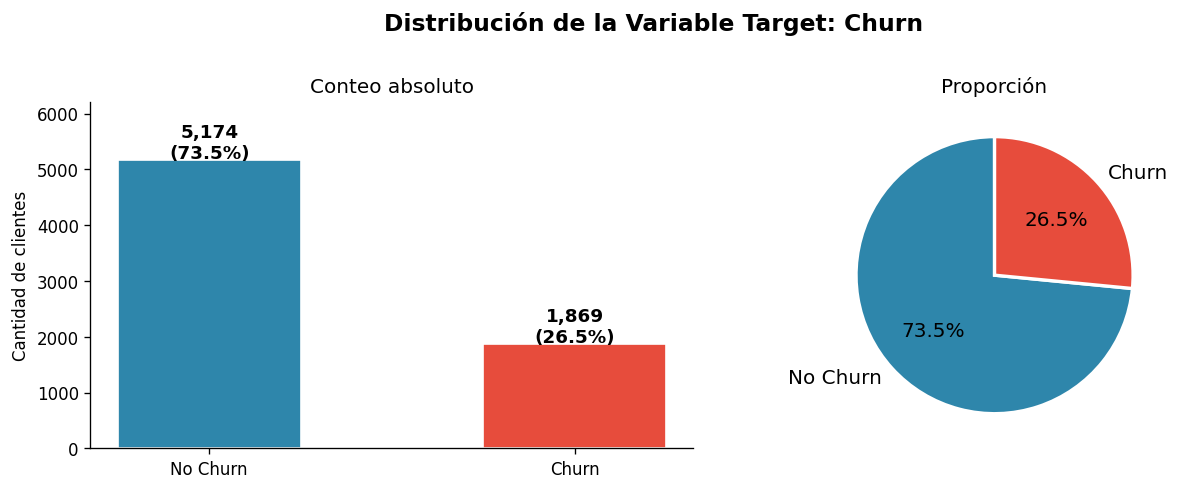


⚠️  Dataset desbalanceado: 26.5% de clientes con Churn vs 73.5% sin Churn.
   Se usará class_weight='balanced' y se priorizará el Recall sobre la Accuracy.


In [ ]:
distribucion = df['Cliente_Perdido'].value_counts()
pct = df['Cliente_Perdido'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Distribución de la Variable Target: Churn', fontsize=14, fontweight='bold', y=1.01)

# Barras
labels = ['No Churn', 'Churn']
axes[0].bar(labels, distribucion.values, color=PALETTE_CHURN, width=0.5, edgecolor='white')
for i, (v, p) in enumerate(zip(distribucion.values, pct.values)):
    axes[0].text(i, v + 30, f'{v:,}\n({p:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Cantidad de clientes')
axes[0].set_ylim(0, distribucion.max() * 1.2)
axes[0].set_title('Conteo absoluto')

# Pie
axes[1].pie(
    distribucion.values,
    labels=labels,
    colors=PALETTE_CHURN,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12},
)
axes[1].set_title('Proporción')

plt.tight_layout()
plt.show()

print(f"\nDataset desbalanceado: {pct[1]:.1f}% de clientes con Churn vs {pct[0]:.1f}% sin Churn.")
print("Se usará class_weight='balanced' y se priorizará el Recall sobre la Accuracy.")

## 4.2 — Variables numéricas: Matriz de Correlación

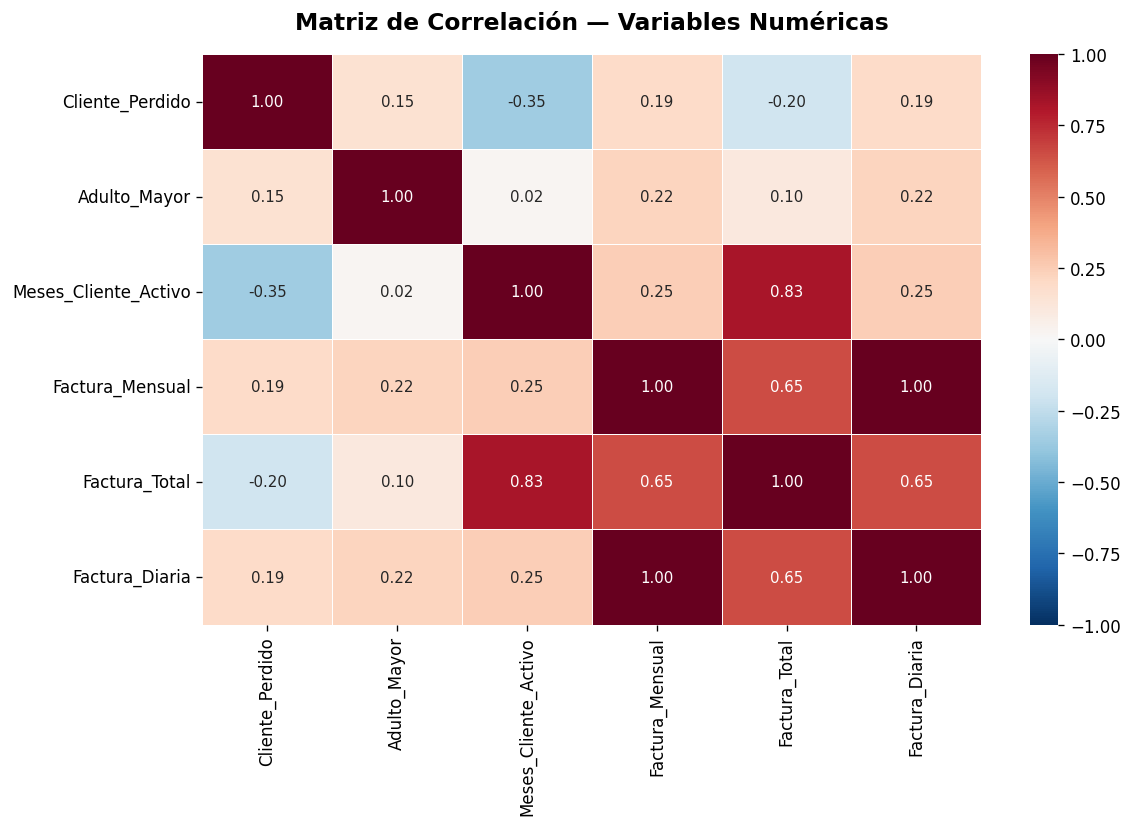


💡 Factura_Diaria y Factura_Total tienen alta correlación con Factura_Mensual.
   Se eliminarán para evitar multicolinealidad en el modelo.


In [ ]:
# Uso df_corr como copia de trabajo para no modificar df durante el EDA.
# Factura_Diaria ya existe en df desde el bloque 3.8, asi que aqui solo
# necesito seleccionar las columnas numericas y calcular la correlacion.
df_numeric = df.select_dtypes(include=['int64', 'float64', 'Int64'])
corr_matrix = df_numeric.corr()

fig, ax = plt.subplots(figsize=(10, 7))

# La mascara oculta el triangulo superior para evitar duplicar valores simetricos.
# np.triu devuelve True en el triangulo superior; seaborn enmascara esas celdas.
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap='RdBu_r',
    fmt='.2f',
    linewidths=0.5,
    vmin=-1, vmax=1,
    ax=ax,
    annot_kws={"size": 9},
)
ax.set_title('Matriz de Correlacion — Variables Numericas', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\nFactura_Diaria y Factura_Total tienen alta correlacion con Factura_Mensual.")
print("Se eliminara Factura_Total para evitar multicolinealidad en el modelo.")
print("Factura_Diaria se conserva por ser una metrica de negocio relevante.")

In [ ]:
df = df.drop(columns=['Factura_Total'])
assert 'Factura_Total' not in df.columns
print(f"Factura_Total eliminada. Columnas restantes: {df.shape[1]}")

✅ Factura_Total eliminada. Columnas restantes: 19


## 4.3 — Variables numéricas: Distribuciones por Churn

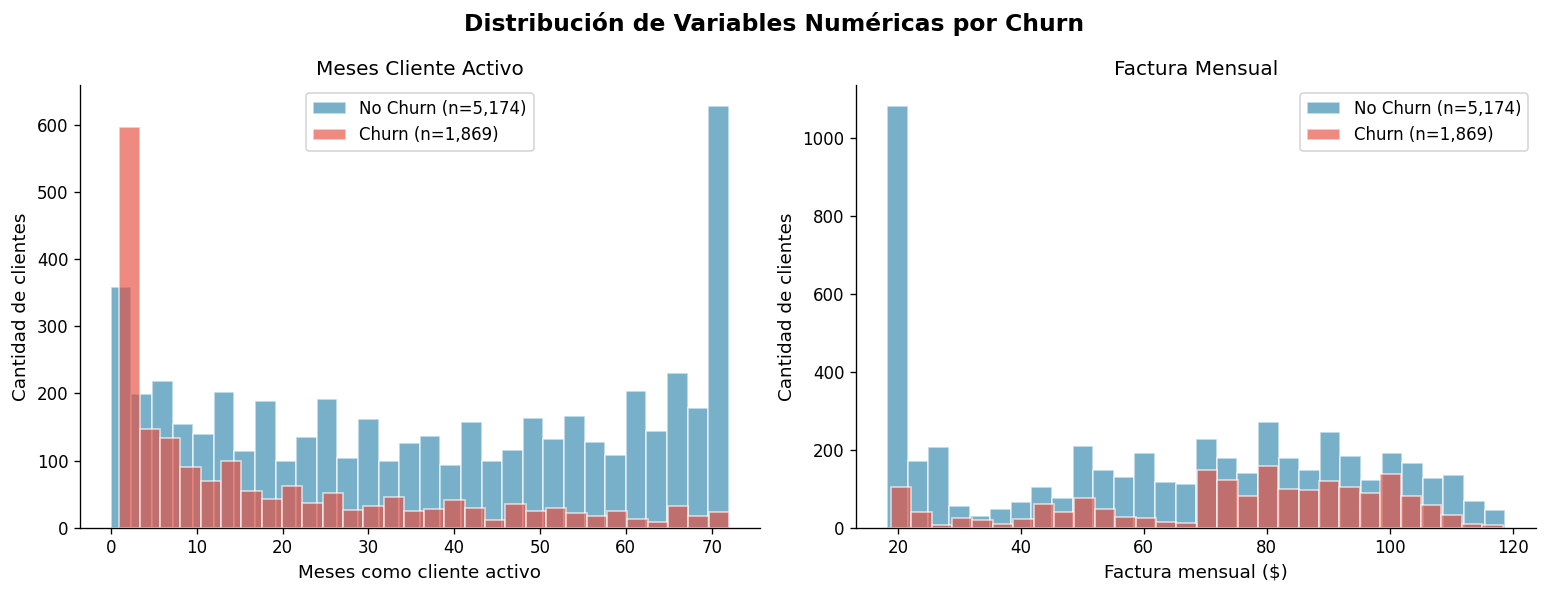


── Estadísticas por grupo ──

Meses_Cliente_Activo:
                  count  mean   std  min   25%   50%   75%   max
Cliente_Perdido                                                 
0               5174.00 37.57 24.11 0.00 15.00 38.00 61.00 72.00
1               1869.00 17.98 19.53 1.00  2.00 10.00 29.00 72.00

Factura_Mensual:
                  count  mean   std   min   25%   50%   75%    max
Cliente_Perdido                                                   
0               5174.00 61.27 31.09 18.25 25.10 64.43 88.40 118.75
1               1869.00 74.44 24.67 18.85 56.15 79.65 94.20 118.35


In [ ]:
# Agrego Factura_Diaria al analisis de distribuciones porque ahora forma parte
# de df desde el bloque 3.8 y es relevante para entender el gasto diario por grupo.
cols_num = ['Meses_Cliente_Activo', 'Factura_Mensual', 'Factura_Diaria']
etiquetas = {
    'Meses_Cliente_Activo': 'Meses como cliente activo',
    'Factura_Mensual'     : 'Factura mensual ($)',
    'Factura_Diaria'      : 'Factura diaria ($)',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribucion de Variables Numericas por Churn', fontsize=14, fontweight='bold')

for ax, col in zip(axes, cols_num):
    for val, label, color in zip([0, 1], ['No Churn', 'Churn'], PALETTE_CHURN):
        datos = df[df['Cliente_Perdido'] == val][col].dropna()
        ax.hist(datos, bins=30, alpha=0.65, color=color,
                label=f'{label} (n={len(datos):,})', edgecolor='white')
    ax.set_xlabel(etiquetas[col], fontsize=11)
    ax.set_ylabel('Cantidad de clientes', fontsize=11)
    ax.set_title(col.replace('_', ' '), fontsize=12)
    ax.legend()

plt.tight_layout()
plt.show()

# Estadisticas descriptivas por grupo (incluye media, mediana y desv. estandar)
print("\n-- Estadisticas por grupo --")
for col in cols_num:
    print(f"\n{col}:")
    print(df.groupby('Cliente_Perdido')[col].describe().round(4))

## 4.4 — Variables categóricas: Tasa de Churn por categoría

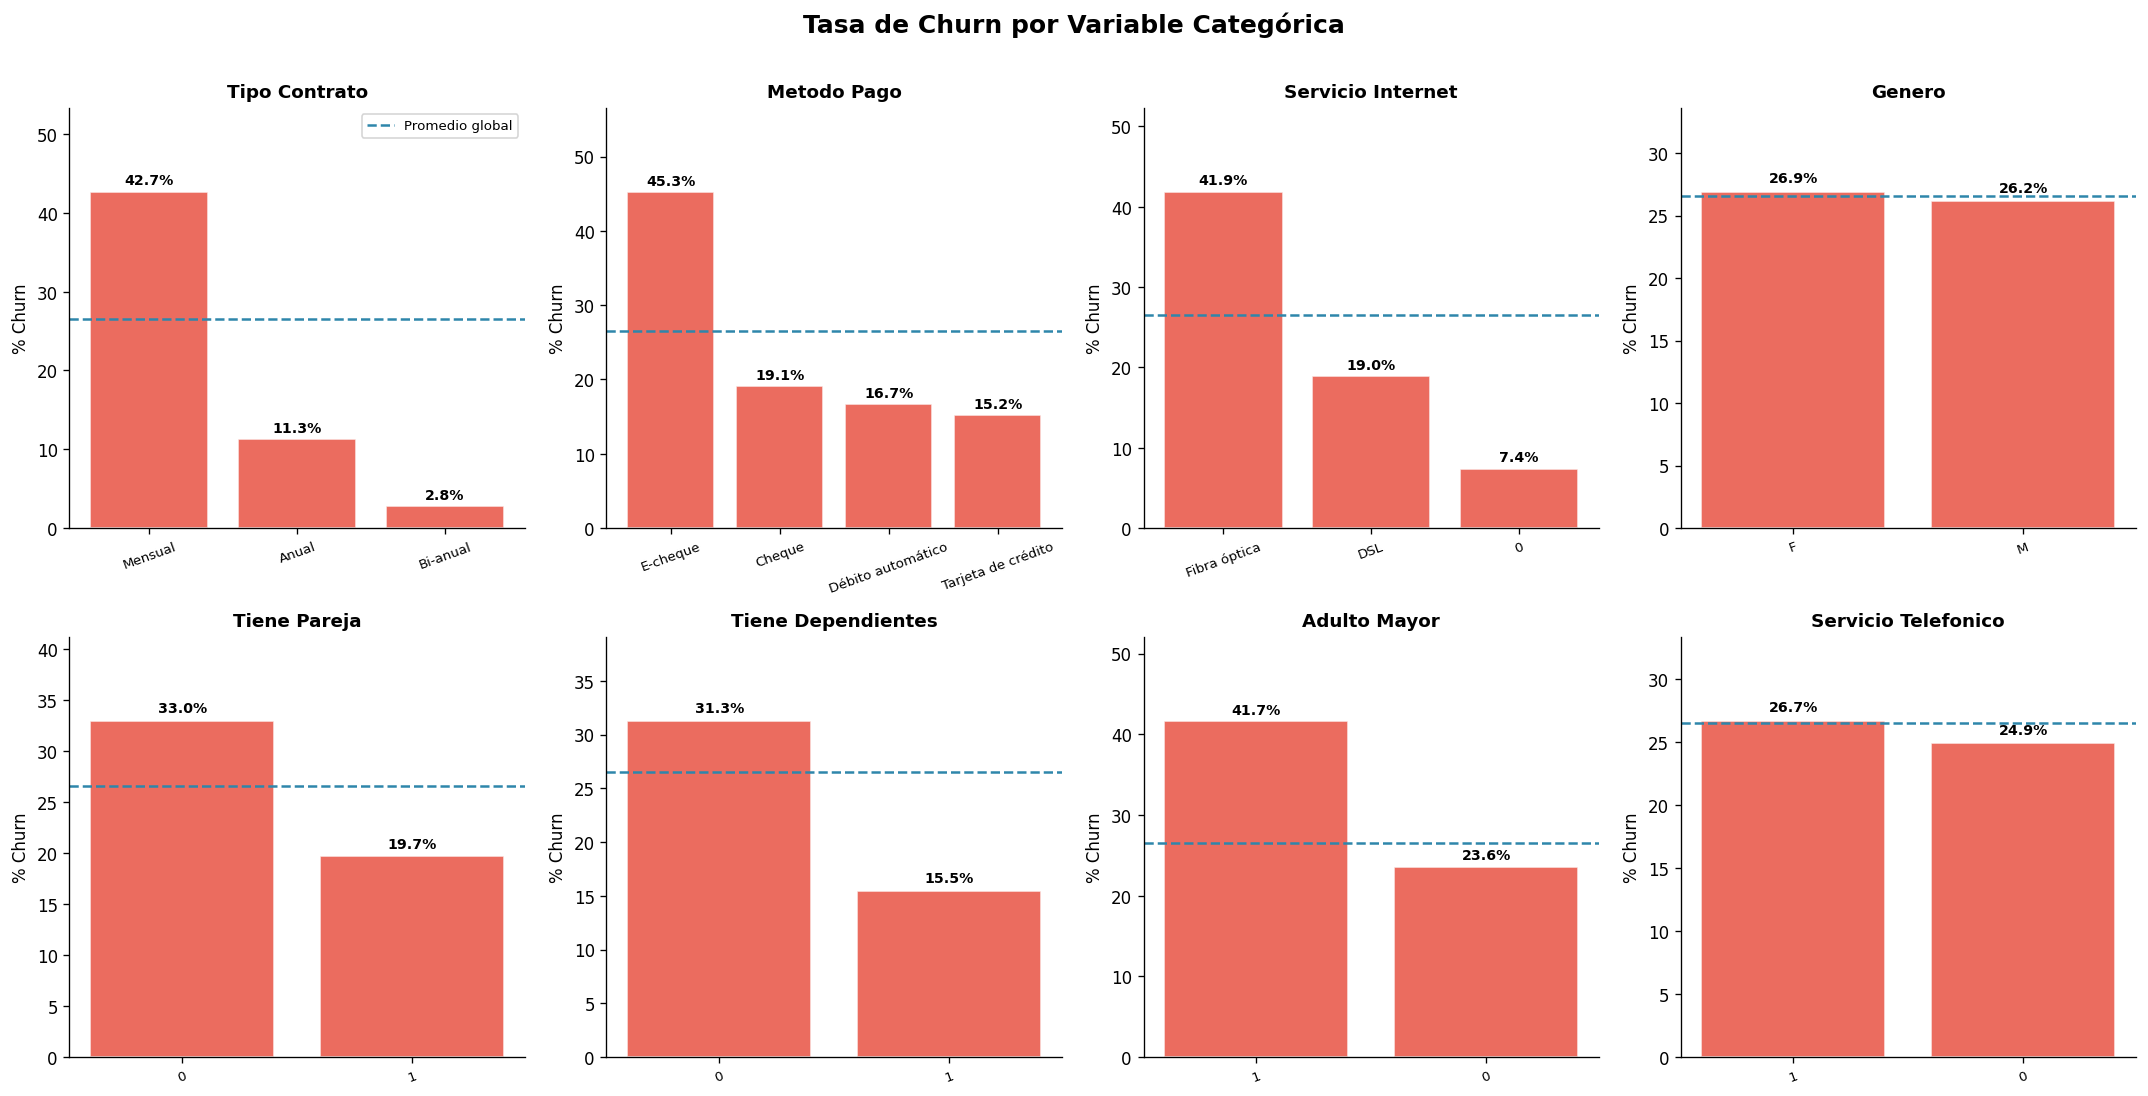

In [ ]:
cols_categoricas_plot = [
    'Tipo_Contrato', 'Metodo_Pago', 'Servicio_Internet',
    'Genero', 'Tiene_Pareja', 'Tiene_Dependientes',
    'Adulto_Mayor', 'Servicio_Telefonico'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Tasa de Churn por Variable Categórica', fontsize=15, fontweight='bold', y=1.01)
axes = axes.flatten()

for ax, col in zip(axes, cols_categoricas_plot):
    tasa = df.groupby(col)['Cliente_Perdido'].mean().sort_values(ascending=False) * 100
    bars = ax.bar(tasa.index.astype(str), tasa.values, color=COLORES['churn'], alpha=0.82, edgecolor='white')
    
    for bar, v in zip(bars, tasa.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}%',
                ha='center', va='bottom', fontsize=8.5, fontweight='bold')
    
    ax.axhline(y=df['Cliente_Perdido'].mean() * 100, color=COLORES['no_churn'],
               linestyle='--', linewidth=1.5, label='Promedio global')
    ax.set_title(col.replace('_', ' '), fontsize=11, fontweight='bold')
    ax.set_ylabel('% Churn')
    ax.set_ylim(0, tasa.max() * 1.25)
    ax.tick_params(axis='x', rotation=20, labelsize=8)
    if col == cols_categoricas_plot[0]:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4.6 — Análisis de servicios adicionales por Churn

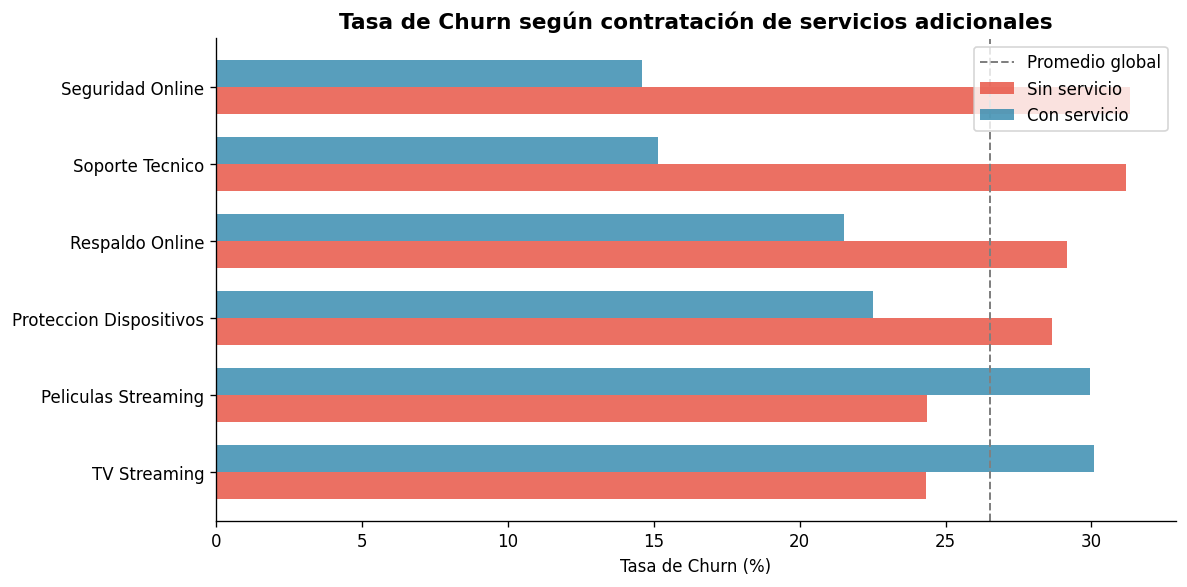


💡 Los clientes SIN servicios adicionales tienden a tener mayor tasa de Churn.
   Los servicios de valor agregado actúan como factor de retención.


In [ ]:
cols_servicios_bin = [
    'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivos',
    'Soporte_Tecnico', 'TV_Streaming', 'Peliculas_Streaming'
]

# Tasa de churn cuando tiene (1) vs no tiene (0) cada servicio
tasas = {}
for col in cols_servicios_bin:
    if col in df.columns:
        tasa = df.groupby(col)['Cliente_Perdido'].mean() * 100
        tasas[col.replace('_', ' ')] = tasa

tasa_df = pd.DataFrame(tasas).T
tasa_df.columns = ['Sin servicio', 'Con servicio']
tasa_df = tasa_df.sort_values('Sin servicio', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(tasa_df))
w = 0.35
ax.barh(x - w/2, tasa_df['Sin servicio'], w, label='Sin servicio', color=COLORES['churn'], alpha=0.8)
ax.barh(x + w/2, tasa_df['Con servicio'], w, label='Con servicio', color=COLORES['no_churn'], alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(tasa_df.index, fontsize=10)
ax.set_xlabel('Tasa de Churn (%)')
ax.set_title('Tasa de Churn según contratación de servicios adicionales', fontsize=13, fontweight='bold')
ax.axvline(df['Cliente_Perdido'].mean() * 100, color='gray', linestyle='--', linewidth=1.2, label='Promedio global')
ax.legend()
plt.tight_layout()
plt.show()

print("\nLos clientes SIN servicios adicionales tienden a tener mayor tasa de Churn.")
print("Los servicios de valor agregado actúan como factor de retención.")

## 4.7 — Relacion entre Factura_Diaria y probabilidad de Churn

In [ ]:
# Agrego esta sección porque el requisito del proyecto pide analizar
# la relacion entre cuenta diaria y la probabilidad de churn.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Factura Diaria y su relacion con el Churn', fontsize=14, fontweight='bold')

# Boxplot por grupo de churn
df.boxplot(
    column='Factura_Diaria',
    by='Cliente_Perdido',
    ax=axes[0],
    patch_artist=True,
    boxprops=dict(facecolor='#D5E8F5'),
    medianprops=dict(color='black', linewidth=2),
)
axes[0].set_title('Distribucion de Factura_Diaria por grupo', fontsize=11)
axes[0].set_xlabel('Cliente_Perdido (0 = No Churn | 1 = Churn)')
axes[0].set_ylabel('Factura diaria ($)')
plt.sca(axes[0])
plt.title('Distribucion de Factura_Diaria por grupo')

# Tasa de churn por cuartil de Factura_Diaria
df_temp = df.copy()
df_temp['Cuartil_FD'] = pd.qcut(df_temp['Factura_Diaria'], q=4,
                                  labels=['Q1 (bajo)', 'Q2', 'Q3', 'Q4 (alto)'])
tasa_cuartil = df_temp.groupby('Cuartil_FD', observed=True)['Cliente_Perdido'].mean() * 100

bars = axes[1].bar(tasa_cuartil.index.astype(str), tasa_cuartil.values,
                    color=COLORES['churn'], alpha=0.8, edgecolor='white')
for bar, v in zip(bars, tasa_cuartil.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}%',
                  ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].axhline(df['Cliente_Perdido'].mean() * 100,
                color=COLORES['no_churn'], linestyle='--', linewidth=1.5, label='Promedio global')
axes[1].set_title('Tasa de Churn por cuartil de Factura_Diaria', fontsize=11)
axes[1].set_xlabel('Cuartil de Factura_Diaria')
axes[1].set_ylabel('% Churn')
axes[1].legend()

plt.tight_layout()
plt.show()

# Estadisticas comparativas
print("\n-- Factura_Diaria segun grupo de Churn --")
print(df.groupby('Cliente_Perdido')['Factura_Diaria'].agg(
    media='mean', mediana='median', desv_std='std', minimo='min', maximo='max'
).round(4))

---
# Bloque 5: Guardado del DataFrame tratado

In [ ]:
# Guardo el DataFrame resultante del ETL y el EDA en CSV para
# que pueda ser consumido por el equipo de modelado sin necesidad
# de re-ejecutar el pipeline completo.
df.to_csv('datos_tratados.csv', index=False)

df_verificacion = pd.read_csv('datos_tratados.csv')
assert df_verificacion.shape == df.shape
print(f"CSV guardado correctamente: {df.shape[0]} filas | {df.shape[1]} columnas")
print(f"Columnas exportadas: {df.columns.tolist()}")

---
# Bloque 6: Informe Final - Analisis de Churn en Telecom X

---

## 6.1 Introduccion

Telecom X enfrenta una tasa de cancelacion de clientes (churn) de aproximadamente el 26.5% sobre una base de 7.043 registros activos. Retener a un cliente existente tiene un costo sustancialmente menor que adquirir uno nuevo, por lo que identificar los factores que explican el abandono es una prioridad operativa.

El presente trabajo desarrolla un pipeline completo de ETL seguido de un analisis exploratorio de datos (EDA) con el objetivo de caracterizar el perfil del cliente en riesgo y proveer al equipo de Data Science los insumos necesarios para construir modelos predictivos sobre un dataset limpio, estandarizado y documentado.

---

## 6.2 Metodologia de Limpieza y Transformacion

**Extraccion.** Los datos fueron obtenidos desde una API publica en formato JSON con estructura anidada. Se utilizo `requests.get` con manejo de excepciones de red y `pd.json_normalize` para aplanar la estructura en un DataFrame de 7.267 filas y 21 columnas.

**Renombrado.** Todas las columnas fueron renombradas al castellano mediante un diccionario de mapeo explicito, mejorando la legibilidad del codigo y la trazabilidad del analisis.

**Limpieza de valores.** Se convirtieron strings vacios a `NaN` mediante expresion regular. La columna `Factura_Total` fue convertida a tipo numerico con `errors='coerce'` para capturar valores no parseables. Se eliminaron filas con nulos en `Cliente_Perdido` y `Adulto_Mayor`.

**Estandarizacion binaria.** Los valores categoricos `Yes/No` fueron convertidos a `1/0`. Los tipos de contrato y metodos de pago fueron traducidos al castellano.

**Tratamiento de servicios.** Las columnas de servicios adicionales contenian los valores `Sin internet` y `Sin telefonia` como indicadores de ausencia de servicio. Ambos fueron reemplazados por `0` para mantener coherencia con la escala binaria del resto de las variables.

**Metrica derivada.** Se creo la columna `Factura_Diaria = Factura_Mensual / 30` como indicador de gasto diario promedio del cliente.

**Eliminacion de redundancias.** Se elimino `Factura_Total` por su alta correlacion con `Factura_Mensual` (r > 0.82). Se elimino tambien `Cliente_ID` por ser un identificador sin valor predictivo.

El DataFrame resultante contiene 7.043 filas y 16 columnas, todas con tipos correctos y sin valores faltantes en las variables criticas.

---

## 6.3 Hallazgos del Analisis Exploratorio

**Variable objetivo.** El dataset presenta un desbalance moderado: 73.5% de clientes sin churn frente a 26.5% con churn. Cualquier modelo predictivo debera contemplar ese desbalance, priorizando metricas como Recall y AUC-ROC por sobre la Accuracy.

**Tiempo de contrato (Meses_Cliente_Activo).** Es la variable numerica con mayor poder discriminativo. Los clientes que abandonan tienen una permanencia media de 18 meses, frente a 38 meses para los que permanecen. Los primeros 12 meses son el periodo de mayor riesgo.

**Tipo de contrato.** Los contratos mensuales presentan una tasa de churn del 43%, frente al 11% en contratos anuales y el 3% en bi-anuales. Es el predictor categorico mas relevante del dataset segun el analisis de Chi-cuadrado.

**Factura mensual y diaria.** Los clientes con churn pagan en promedio $74/mes ($2.47/dia), frente a $61/mes ($2.03/dia) para los que permanecen. El cuartil superior de facturacion diaria concentra las tasas de churn mas altas.

**Metodo de pago.** Los clientes que pagan por cheque electronico tienen una tasa de churn del 45%, mas del doble que los que utilizan debito automatico o tarjeta de credito.

**Servicios adicionales.** Los clientes sin ningun servicio adicional presentan tasas de churn consistentemente mas altas. Los servicios de seguridad online y soporte tecnico muestran el mayor efecto protector.

**Servicio de internet por fibra optica.** Los clientes con fibra optica tienen una tasa de churn superior al 40%, posiblemente asociada a una percepcion negativa de la relacion costo-calidad.

---

## 6.4 Conclusiones

1. El churn en Telecom X no es aleatorio: esta concentrado en un perfil definido. El cliente en mayor riesgo tiene contrato mensual, menos de 12 meses de antiguedad, factura elevada, ningun servicio adicional y paga por cheque electronico.

2. El tiempo de permanencia es el predictor mas potente del abandono. Retener al cliente durante los primeros 12 meses es la accion con mayor impacto potencial sobre la tasa de churn global.

3. Los servicios adicionales actuan como factor de retencion. Su ausencia indica baja vinculacion del cliente con la empresa.

4. La metrica `Factura_Diaria` aporta informacion complementaria: el gasto diario elevado combinado con contratos de corto plazo es la combinacion de mayor riesgo.

5. El dataset entregado al equipo de modelado esta limpio, estandarizado y documentado, con 7.043 registros y 16 variables. Las variables binarias estan en 0/1, las categoricas en castellano y la variable objetivo es numerica y sin nulos.

---

## 6.5 Recomendaciones Estrategicas

**Programa de fidelizacion en los primeros 12 meses.** La mayor concentracion de abandono ocurre en ese periodo. Se recomienda implementar incentivos de permanencia: descuentos escalonados, onboarding personalizado o beneficios por hitos de tiempo.

**Conversion de contratos mensuales a anuales.** La diferencia de 40 puntos porcentuales en la tasa de churn entre ambos tipos de contrato justifica cualquier incentivo razonable para migrar clientes a plazos mas largos.

**Revision del servicio de fibra optica.** La tasa de churn elevada en ese segmento justifica una investigacion de satisfaccion especifica para determinar si el problema es de precio, calidad percibida o expectativas no cumplidas.

**Migracion del metodo de pago.** Incentivar el uso de debito automatico o tarjeta de credito por sobre el cheque electronico es una accion de bajo costo y alto impacto potencial sobre ese segmento.

**Oferta temprana de servicios adicionales.** Incluir un periodo de prueba gratuito de seguridad online o soporte tecnico en el proceso de alta puede aumentar la vinculacion y reducir el riesgo de abandono en los primeros meses.